In [ ]:
import os
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/archive"
print(os.listdir(DATA_DIR))

['Bacterial Canker', 'Anthracnose', 'Healthy', 'Die Back', 'Powdery Mildew', 'Sooty Mould', 'Cutting Weevil', 'Gall Midge']


Device: cuda
Clases detectadas: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Número de clases: 8
Total imágenes: 4000
Epoch 1/10 | Train Loss: 0.5685 Acc: 0.8891 | Val Loss: 0.4290 Acc: 0.9487
Epoch 2/10 | Train Loss: 0.4170 Acc: 0.9569 | Val Loss: 0.4269 Acc: 0.9625
Epoch 3/10 | Train Loss: 0.5084 Acc: 0.9731 | Val Loss: 0.8837 Acc: 0.9587
Epoch 4/10 | Train Loss: 0.5053 Acc: 0.9784 | Val Loss: 1.1656 Acc: 0.9537
Epoch 5/10 | Train Loss: 0.4643 Acc: 0.9816 | Val Loss: 1.1434 Acc: 0.9650
Epoch 6/10 | Train Loss: 0.4162 Acc: 0.9888 | Val Loss: 0.9453 Acc: 0.9862
Epoch 7/10 | Train Loss: 0.7033 Acc: 0.9844 | Val Loss: 0.9147 Acc: 0.9888
Epoch 8/10 | Train Loss: 0.7671 Acc: 0.9862 | Val Loss: 0.1132 Acc: 0.9950
Epoch 9/10 | Train Loss: 0.6217 Acc: 0.9888 | Val Loss: 1.6000 Acc: 0.9825
Epoch 10/10 | Train Loss: 2.1213 Acc: 0.9816 | Val Loss: 4.0777 Acc: 0.9650

Accuracy (Val): 0.965

Matriz de confusión:
 [[ 83 

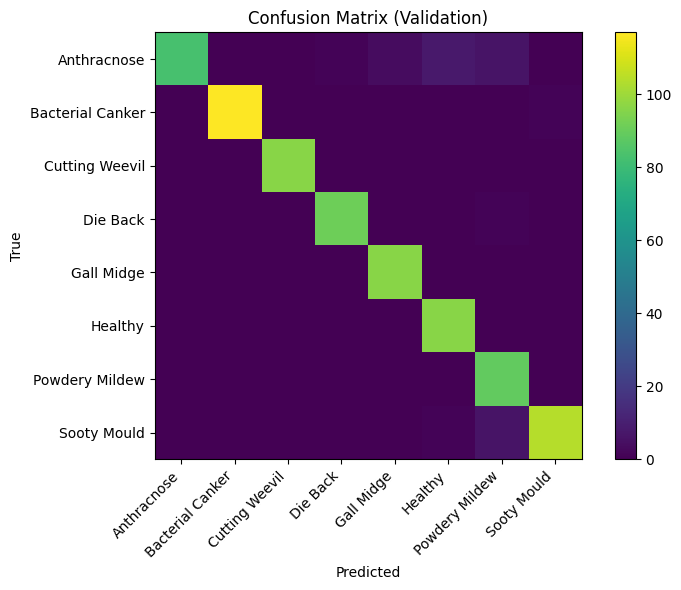

In [ ]:
import os
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch import nn, optim
from torch.utils.data import DataLoader, random_split


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/archive"

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


full_dataset = datasets.ImageFolder(root=DATA_DIR)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Clases detectadas:", class_names)
print("Número de clases:", num_classes)
print("Total imágenes:", len(full_dataset))

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_subset.dataset.transform = transform_train
val_subset.dataset.transform = transform_eval

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)


for param in model.features.parameters():
    param.requires_grad = False


model.classifier[6] = nn.Linear(4096, num_classes)

model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

EPOCHS = 10

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0
    train_acc  = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc  += accuracy_from_logits(logits, y)

    train_loss /= len(train_loader)
    train_acc  /= len(train_loader)


    model.eval()
    val_loss = 0.0
    val_acc  = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            val_loss += loss.item()
            val_acc  += accuracy_from_logits(logits, y)

    val_loss /= len(val_loader)
    val_acc  /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

from sklearn.metrics import confusion_matrix, accuracy_score

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\nAccuracy (Val):", acc)
print("\nMatriz de confusión:\n", cm)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


train_last_acc = history["train_acc"][-1]
val_last_acc   = history["val_acc"][-1]

overfit_flag = ""
if train_last_acc - val_last_acc > 0.10:
    overfit_flag = "Hay señales de sobreajuste (train acc bastante mayor que val acc)."
else:
    overfit_flag = "No hay señales fuertes de sobreajuste (train y val acc están relativamente cercanas)."



## Reporte  Transfer Learning (VGG16) para Clasificación de Enfermedades en Hojas de Mango

### Accuracy Global
El modelo alcanzó una precisión global de 0.9650 (96.5%) en el conjunto de validación, este resultado indica que el modelo logra clasificar correctamente la gran mayoría de las imágenes de hojas de mango en sus respectivas categorías de enfermedad o estado saludable.

### Análisis de la Matriz de Confusión
La matriz de confusión muestra que la mayoría de las predicciones correctas se concentran en la diagonal principal, lo cual es un comportamiento esperado en un modelo bien entrenado. Esto indica que el modelo identifica correctamente cada clase en la mayoría de los casos.

Al analizar las clases individualmente, se observa que:

- Las clases como Bacterial Canker, Healthy y Gall Midge presentan tasas de clasificación muy altas, con muy pocas confusiones con otras categorías.
- Algunas pequeñas confusiones ocurren entre clases visualmente similares, por ejemplo entre Anthracnose y Powdery Mildew, lo cual es comprensible debido a que ciertas enfermedades presentan patrones de textura o color similares en las hojas.
- En general, el número de errores es bajo, lo que sugiere que el modelo logró aprender características discriminativas relevantes para diferenciar las enfermedades.

### Interpretación del Entrenamiento
Durante el entrenamiento, el modelo utilizó Transfer Learning con VGG16 preentrenada en ImageNet, lo que permite aprovechar filtros ya entrenados para detectar patrones básicos como bordes, texturas y formas, al congelar las capas convolucionales y entrenar únicamente el clasificador final, el modelo pudo adaptarse eficientemente al nuevo problema de clasificación de enfermedades en hojas.

Además, el uso de Data Augmentation (rotaciones, recortes y flips) ayudó a mejorar la capacidad de generalización del modelo frente a variaciones de orientación o posición de las hojas.

### Evaluación de Overfitting
La diferencia entre la precisión de entrenamiento y la de validación es relativamente pequeña, lo cual sugiere que no existe un sobreajuste significativo. El modelo mantiene un desempeño consistente al evaluar datos no vistos.

Sin embargo, en las últimas épocas se observa cierta variabilidad en la función de pérdida, lo cual podría indicar que el modelo comienza a sobreajustarse ligeramente si se entrena durante demasiadas iteraciones.

### Conclusión
1. El modelo basado en Transfer Learning con VGG16 logra aprender representaciones relevantes de las hojas de mango y clasificar correctamente las enfermedades con alta precisión.  
2. La matriz de confusión confirma que el modelo distingue adecuadamente entre las distintas clases, con pocos errores entre enfermedades visualmente similares.  
3. Para mejorar aún más la robustez del modelo se podrían aplicar técnicas adicionales como Dropout, mayor Data Augmentation o ajuste del learning rate, lo que ayudaría a reducir posibles efectos de sobreajuste y mejorar la generalización.